# Near Surface Winds from CERRA and ERA5: Ciarán

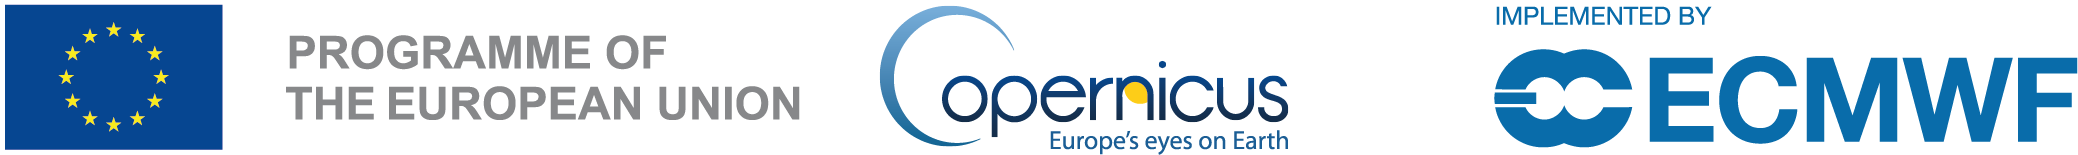

**Last updated:** 2026-06-01

This notebook will showcase how to download data for wind speed from the Copernicus Data Storage, open it and plot it, for CERRA and ERA5. The storm Ciarán is chosen as a case study, but the script can be easily modified to accomodate other events. 

## Fetching ERA5 and CERRA Data
### Install CDS API
Before we begin we must prepare our environment. This includes installing the Application Programming Interface (API) of the CDS, and importing the various python libraries that we will need. To install the CDS API, run the following command.

In [1]:
#!pip install cdsapi #Uncomment this part if cdsapi is not installed

We will also use Climate Data Operators (cdo) for doing some of the heavier calculations, such as regridding. To install the python version of cdo, run the following cell.

In [ ]:
#!pip install cdo  #Uncomment this part if cdo is not installed

For plotting maps, we will use the module cartopy. This is sometimes not installed in local machines, so run the following cell to install it. 

In [ ]:
#!pip install cartopy #Uncomment this part if cartopy is not installed

#### Enter Your CDS API key
We will request data from the Climate Data Store (CDS) with the help of the CDS API. To do this, you need to pass your personal URL and KEY that together for your CDS API key. To obtain these, register or login to CDS and visit https://cds.climate.copernicus.eu/how-to-api. Copy the string of characters listed after "key" and replace the #### in the code below. 

In [145]:
import cdsapi

URL = "https://cds.climate.copernicus.eu/api"
KEY = "#####"
client = cdsapi.Client(url=URL, key=KEY)

Now we will load the python packages used for downloading, analysing and plotting the data. 

In [ ]:
import cdo
import xarray as xr
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

# And some stuff for fancy plotting - uncomment if needed
# from cartopy.mpl.geoaxes import GeoAxes
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes
# from matplotlib.patches import ConnectionPatch
# from mpl_toolkits.axes_grid1 import make_axes_locatable
# from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

cdo = cdo.Cdo()

### Preparing Working Directories 
We will download the CERRA, ERA5 and E-OBS data for the period 30th of October to 5th of November 2023. Since this range stretches over two months, we will do two seperate downloads and then merge them. First we need to specify the working directory, where we want the data to be downloaded to. The default is in the scratch directory of the user, but feel free to change this. The script will check if there are folders for "CERRA" and "ERA", and if not, it will create them in the working directory. 

In [2]:
HOME = os.path.expanduser("~")
SCRATCH = os.environ.get("SCRATCH", "/tmp")
WRKDIR = SCRATCH  # change this if needed

print(f"Working directory: {WRKDIR}")

Working directory: /ec/res4/scratch/swe1249


In [3]:
DATADIR = os.path.join(WRKDIR, "CERRA")
if not os.path.isdir(DATADIR):
    os.makedirs(DATADIR)
fCERRA1 = os.path.join(DATADIR, "WS_" + "period1" + ".grb")
fCERRA2 = os.path.join(DATADIR, "WS_" + "period2" + ".grb")
fCERRA = os.path.join(DATADIR, "WS_total_period" + ".grb")

DATADIR = os.path.join(WRKDIR, "ERA")
if not os.path.isdir(DATADIR):
    os.makedirs(DATADIR)
fERA1 = os.path.join(DATADIR, "WS_" + "period1" + ".nc")
fERA2 = os.path.join(DATADIR, "WS_" + "period2" + ".nc")
fERA = os.path.join(DATADIR, "WS_total_period.nc")

print(f"Will be saving data in files: \n{fCERRA}\n{fERA}")

Will be saving data in files: 
/ec/res4/scratch/swe1249/CERRA/WS_total_period.grb
/ec/res4/scratch/swe1249/ERA/WS_total_period.nc


### Downloading the Data
Next we make some help functions that help us download the data using the api request format. 

In [149]:
def download_cerra(year, month, days, file):
    dataset = "reanalysis-cerra-single-levels"
    request = {
        "variable": ["10m_wind_speed"],
        "level_type": "surface_or_atmosphere",
        "data_type": ["reanalysis"],
        "product_type": "forecast",
        "year": [year],
        "month": [month],
        "day": days,
        "time": [
            "00:00",
            "03:00",
            "06:00",
            "09:00",
            "12:00",
            "15:00",
            "18:00",
            "21:00",
        ],
        "leadtime_hour": ["1"],
        "data_format": "grib",
    }
    client.retrieve(dataset, request, file)


def download_era(year, month, days, file):
    dataset = "reanalysis-era5-single-levels"
    request = {
        "product_type": "reanalysis",
        "variable": ["10m_u_component_of_wind", "10m_v_component_of_wind"],
        "year": [f"{year}"],
        "month": [f"{month}"],
        "day": days,
        "time": [
            "00:00",
            "03:00",
            "06:00",
            "09:00",
            "12:00",
            "15:00",
            "18:00",
            "21:00",
        ],
        "area": [80, -60, 20, 75],
        "format": "netcdf",
    }
    client.retrieve(dataset, request, file)

We define the two periods we will be downloading data for, and send in the requests. The download might take some time. We will merge the two files into one using the CDO operator "mergetime".

In [150]:
year = 2023
month1, month2 = 10, 11
days1, days2 = ["30", "31"], ["01", "02", "03", "04", "05"]

download_cerra(year, month1, days1, fCERRA1)
download_cerra(year, month2, days2, fCERRA2)

download_era(year, month1, days1, fERA1)
download_era(year, month2, days2, fERA2)

2026-01-12 11:51:24,441 INFO Request ID is e9367fd8-f18c-49b4-a7ef-041c8b551d80
2026-01-12 11:51:24,474 INFO status has been updated to accepted
2026-01-12 11:51:45,411 INFO status has been updated to successful


ca83cc52b111646d61ec8fc91bd8ba39.grib:   0%|          | 0.00/34.9M [00:00<?, ?B/s]

2026-01-12 11:51:45,906 INFO Request ID is 52acc85e-a0db-433d-9768-fbcedc120dfe
2026-01-12 11:51:45,965 INFO status has been updated to accepted
2026-01-12 11:51:59,326 INFO status has been updated to successful


40967baeddb4e73322f5787ddf3ca58e.grib:   0%|          | 0.00/87.2M [00:00<?, ?B/s]

2026-01-12 11:52:00,282 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-01-12 11:52:00,283 INFO Request ID is a85cf024-f527-4ea5-9dc3-638f4b4beefa
2026-01-12 11:52:00,438 INFO status has been updated to accepted
2026-01-12 11:52:13,720 INFO status has been updated to successful


2ff291fa60fc6e6aed13d3a104eed277.nc:   0%|          | 0.00/8.27M [00:00<?, ?B/s]

2026-01-12 11:52:14,194 INFO [2025-12-11T00:00:00] Please note that a dedicated catalogue entry for this dataset, post-processed and stored in Analysis Ready Cloud Optimized (ARCO) format (Zarr), is available for optimised time-series retrievals (i.e. for retrieving data from selected variables for a single point over an extended period of time in an efficient way). You can discover it [here](https://cds.climate.copernicus.eu/datasets/reanalysis-era5-single-levels-timeseries?tab=overview)
2026-01-12 11:52:14,195 INFO Request ID is bf2cd213-0256-4ea7-b347-a3ffbecc3faf
2026-01-12 11:52:14,216 INFO status has been updated to accepted
2026-01-12 11:52:28,111 INFO status has been updated to running
2026-01-12 11:52:35,724 INFO status has been updated to successful


27218f84ae985a5b4572064ccf90fd42.nc:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

In [151]:
def mergetime(f1, f2, fout):
    cdo.mergetime(input=f"{f1} {f2}", output=fout)


mergetime(fCERRA1, fCERRA2, fCERRA)
mergetime(fERA1, fERA2, fERA)

### Interpolate Data to a Common Grid
Before plotting the two data sets we need to have them first in the same grid. We use the CDO library to interpolate the ERA5 data into the CERRA grid for a fair comparison. 

In [154]:
def remap_to_cerra_grid(
    source_file, cerra_grid_file, output_nc, fmt="nc4", zip_level=4
):
    options = f"-f {fmt} -z zip_{zip_level}" if fmt in ("nc4", "nc4c") else f"-f {fmt}"
    cdo.remapbil(cerra_grid_file, input=source_file, output=output_nc, options=options)

In [153]:
fERA_CERRA_grid = os.path.join(WRKDIR, "ERA", "WS_on_CERRA_grid.nc")

In [156]:
remap_to_cerra_grid(fERA, fCERRA, fERA_CERRA_grid)

## Plotting the Data
We will now plot the data we have downloaded. We will make small maps for the daily maximum wind speed, comparing the ERA5 and CERRA data. First, we open the data and find the daily maximum wind speed and the daily mean wind speed. Note that we have downloaded both the u and v component of the wind speed from the ERA5 data, so we calculate the wind speed as $U=\sqrt{u^2+v^2}$.

In [ ]:
cerra_ds = xr.open_dataset(fCERRA)
var = "si10"
cerra_ds = cerra_ds.assign_coords(longitude=(((cerra_ds.longitude + 180) % 360) - 180))
cerra_daily_max = cerra_ds[var].resample(time="D").max()
cerra_daily_mean = cerra_ds["si10"].resample(time="D").mean()

era_ds = xr.open_dataset(fERA_CERRA_grid)
era_ds = (
    era_ds.rename({"valid_time": "time"}) if "valid_time" in era_ds.dims else era_ds
)
wind_speed_data = np.sqrt(era_ds["u10"] ** 2 + era_ds["v10"] ** 2)
wind_speed = xr.DataArray(wind_speed_data, coords=era_ds.coords, dims=era_ds.dims)
era_ds["wind_speed"] = wind_speed
era_ds = era_ds.assign_coords(longitude=cerra_ds.longitude)
era_ds = era_ds.assign_coords(lattiude=cerra_ds.latitude)
era_daily_max = era_ds["wind_speed"].resample(time="D").max()
era_daily_mean = era_ds["wind_speed"].resample(time="D").max()

Next we plot the two datasets side by side. First we need some projection things; 

In [ ]:
lats = cerra_daily_max.latitude
lons = cerra_daily_max.longitude

proj = ccrs.LambertConformal(
    central_latitude=50.0,
    central_longitude=8.0,
    standard_parallels=(50.0,),
    false_easting=2937000.04508007,
    false_northing=2937000.00945589,
    globe=ccrs.Globe(semimajor_axis=6371229.0, semiminor_axis=6371229.0),
)

And now we can plot. First, we plot the daily maximum wind speed for both CERRA and ERA5 over the event (two days before the storm, the three days during the storm and two days after the storm). 

Working on row 0...
Working on row 1...
Working on row 2...
Working on row 3...
Working on row 4...
Working on row 5...
Working on row 6...


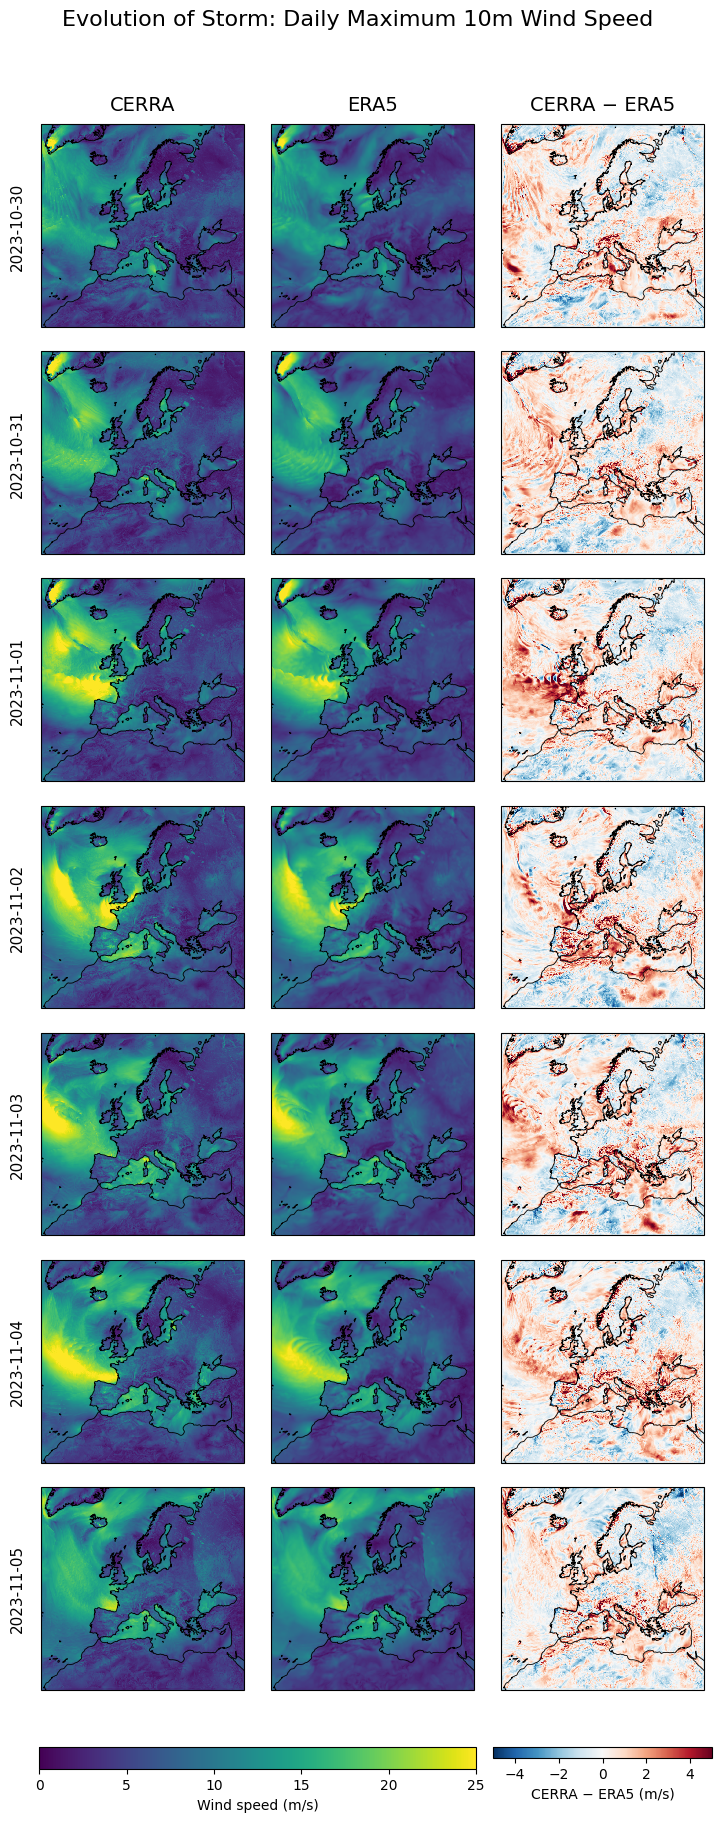

In [216]:
time = cerra_daily_max["time"]
nrows = len(time)

fig, axs = plt.subplots(nrows, 3, figsize=(7.5, 23), subplot_kw={"projection": proj})
fig.subplots_adjust(
    left=0.06, right=0.98, top=0.93, bottom=0.10, wspace=0.0, hspace=0.12
)

axs[0, 0].set_title("CERRA", fontsize=14, pad=10)
axs[0, 1].set_title("ERA5", fontsize=14, pad=10)
axs[0, 2].set_title("CERRA − ERA5", fontsize=14, pad=10)

m_speed = None
m_diff = None

for i in range(nrows):
    print(f"Working on row {i}...")
    date = pd.to_datetime(time[i].values).strftime("%Y-%m-%d")
    axs[i, 0].text(
        -0.08,
        0.5,
        date,
        transform=axs[i, 0].transAxes,
        rotation=90,
        va="center",
        ha="right",
        fontsize=11,
    )
    cer = cerra_daily_max.isel(time=i)
    era = era_daily_max.isel(time=i)
    panels = [
        (cer, 0, 25, "viridis"),
        (era, 0, 25, "viridis"),
        (cer - era, -5, 5, "RdBu_r"),
    ]
    for j, (data, vmin, vmax, cmap) in enumerate(panels):
        ax = axs[i, j]
        pm = ax.pcolormesh(
            lons,
            lats,
            data,
            transform=ccrs.PlateCarree(),
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )
        ax.coastlines(resolution="50m", linewidth=0.6)
        ax.set_xticks([])
        ax.set_yticks([])
        if j in (0, 1) and m_speed is None:
            m_speed = pm
        if j == 2 and m_diff is None:
            m_diff = pm

cbar1 = fig.colorbar(
    m_speed, ax=axs[:, :2], orientation="horizontal", shrink=0.95, pad=0.03
)
cbar1.set_label("Wind speed (m/s)")

cbar2 = fig.colorbar(
    m_diff, ax=axs[:, 2], orientation="horizontal", shrink=0.95, pad=0.03
)
cbar2.set_label("CERRA − ERA5 (m/s)")

fig.suptitle("Evolution of Storm: Daily Maximum 10m Wind Speed", fontsize=16)
plt.show()

## Downloading Observations
We download the observational data as gridded dataset over land from CDS, following the same format as for CERRA and ERA5. The only difference is that the E-OBS are sectioned into larger period of time, so we will download the data 2011-2024, and then make a subsection of this data with the relevant time period.

In [7]:
DATADIR = os.path.join(WRKDIR, "OBSERVATIONS")
if not os.path.isdir(DATADIR):
    os.makedirs(DATADIR)
fEOBS_ZIP = os.path.join(DATADIR, "WS_total.zip")
fEOBS_TOTAL = os.path.join(DATADIR, "WS_" + "total" + ".nc")
fEOBS_SUB = os.path.join(DATADIR, "WS_subsection.nc")
fEOBS_CERRA_GRID = os.path.join(DATADIR, "WS_subsection_on_CERRA.nc")

print(
    f"Will be saving data in files: \n{fEOBS_ZIP}\n{fEOBS_TOTAL}\n{fEOBS_SUB}\n{fEOBS_CERRA_GRID}"
)

Will be saving data in files: 
/ec/res4/scratch/swe1249/OBSERVATIONS/WS_total.zip
/ec/res4/scratch/swe1249/OBSERVATIONS/WS_total.nc
/ec/res4/scratch/swe1249/OBSERVATIONS/WS_subsection.nc
/ec/res4/scratch/swe1249/OBSERVATIONS/WS_subsection_on_CERRA.nc


In [19]:
def download_observations(period, file):
    dataset = "insitu-gridded-observations-europe"
    request = {
        "product_type": "ensemble_mean",
        "variable": ["wind_speed"],
        "grid_resolution": "0_1deg",
        "period": period,
        "version": ["31_0e"],
    }
    client.retrieve(dataset, request, file)

In [20]:
download_observations("2011_2024", fEOBS_ZIP)

2026-01-11 14:31:14,421 INFO Request ID is 34aec4d2-cad6-4938-861d-cfb8b70b8619
2026-01-11 14:31:14,451 INFO status has been updated to accepted
2026-01-11 14:31:24,112 INFO status has been updated to running
2026-01-11 14:31:29,210 INFO status has been updated to successful


2371a5a3bb97787d74cb953767588ca1.zip:   0%|          | 0.00/604M [00:00<?, ?B/s]

The data is downloaded into a zip file which needs to be extracted. This can be done either using the package zipfile, or manually. 

In [26]:
import zipfile

nc_paths = []

with zipfile.ZipFile(fEOBS_ZIP, "r") as z:
    for name in z.namelist():
        if name.endswith(".nc"):
            z.extract(name, DATADIR)
            nc_paths.append(os.path.join(DATADIR, name))

os.rename(nc_paths[0], fEOBS_TOTAL)

['/ec/res4/scratch/swe1249/OBSERVATIONS/fg_ens_mean_0.1deg_reg_2011-2024_v31.0e.nc']
/ec/res4/scratch/swe1249/OBSERVATIONS/WS_total.nc


Now we just want to select the correct dates, and regridd the data to CERRA's resolution. 

In [37]:
cdo.seldate("2023-10-30,2023-11-5", input=fEOBS_TOTAL, output=fEOBS_SUB)
remap_to_cerra_grid(fEOBS_SUB, fCERRA, fEOBS_CERRA_GRID)

Once the data is regridded, we can open it. The observations are already daily means of the wind speed, so when comparing the datasets from now on, the daily mean will be used. 

In [217]:
obsar_raw = xr.open_dataset(fEOBS_CERRA_GRID)
obs_daily_mean = obsar_raw["fg"]

## Comparing CERRA, ERA5 & E-OBS
To compare the three datasets, we start by looking at the event-mean of the wind speed, and find the bias of CERRA and ERA5. This is plotted in maps below. 

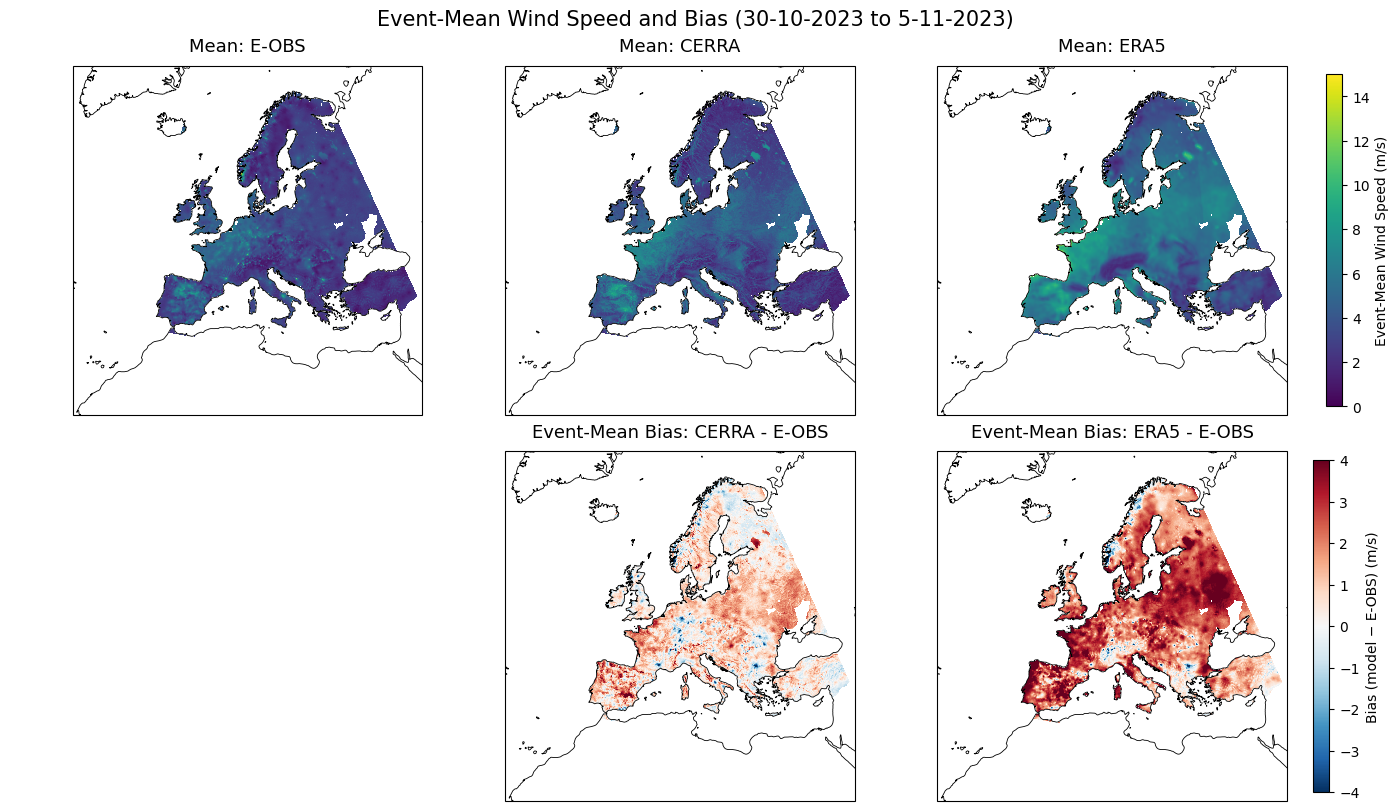

In [ ]:
cer_mean_ev = cerra_daily_mean.mean(dim="time", skipna=True)
era_mean_ev = era_daily_mean.mean(dim="time", skipna=True)
obs_mean_ev = obs_daily_mean.mean(dim="time", skipna=True)

mask = np.isfinite(obs_mean_ev)
cer_mean_m = cer_mean_ev.where(mask)
era_mean_m = era_mean_ev.where(mask)

bias_cer = (cer_mean_ev - obs_mean_ev).where(mask)
bias_era = (era_mean_ev - obs_mean_ev).where(mask)

fig, axs = plt.subplots(
    2, 3, figsize=(14, 8), subplot_kw={"projection": proj}, constrained_layout=True
)
axs[0, 0].set_title("Mean: E-OBS", fontsize=13, pad=10)
axs[0, 1].set_title("Mean: CERRA", fontsize=13, pad=10)
axs[0, 2].set_title("Mean: ERA5", fontsize=13, pad=10)
axs[1, 0].set_title("", fontsize=13, pad=10)
axs[1, 1].set_title("Event-Mean Bias: CERRA - E-OBS", fontsize=13, pad=10)
axs[1, 2].set_title("Event-Mean Bias: ERA5 - E-OBS", fontsize=13, pad=10)

vmax_speed = 15
vmax_bias = 4

panels = {
    (0, 0): (obs_mean_ev, 0, vmax_speed, "viridis"),
    (0, 1): (cer_mean_m, 0, vmax_speed, "viridis"),
    (0, 2): (era_mean_m, 0, vmax_speed, "viridis"),
    (1, 0): (None, None, None, None),
    (1, 1): (bias_cer, -vmax_bias, vmax_bias, "RdBu_r"),
    (1, 2): (bias_era, -vmax_bias, vmax_bias, "RdBu_r"),
}

m_speed = None
m_bias = None

for (r, c), (data, vmin, vmax, cmap) in panels.items():
    ax = axs[r, c]
    if data is None:
        ax.axis("off")
        continue
    pm = ax.pcolormesh(
        lons,
        lats,
        data,
        transform=ccrs.PlateCarree(),
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )
    ax.coastlines(resolution="50m", linewidth=0.6)
    ax.set_xticks([])
    ax.set_yticks([])
    if r == 0 and m_speed is None:
        m_speed = pm
    if r == 1 and c in (1, 2) and m_bias is None:
        m_bias = pm

cbar1 = fig.colorbar(
    m_speed, ax=axs[0, :], orientation="vertical", shrink=0.95, pad=0.03
)
cbar1.set_label("Event-Mean Wind Speed (m/s)")
cbar2 = fig.colorbar(
    m_bias, ax=axs[1, 1:], orientation="vertical", shrink=0.95, pad=0.03
)
cbar2.set_label("Bias (model − E-OBS) (m/s)")

fig.suptitle("Event-Mean Wind Speed and Bias (30-10-2023 to 5-11-2023)", fontsize=15)
plt.show()

## Timeseries of Grid Cells
Lastly we look at a timeseries for the wind speed of the grid cell closest to a given coordinate. 

In [ ]:
def point_timeseries_with_locator(
    lat0, lon0, cerra_ds, era_ds, obs_ds, cerra_var, era_var, obs_var, time_step
):
    pad = 120

    cer = cerra_ds[cerra_var]
    era = era_ds[era_var]
    obs = obs_ds[obs_var]

    lat2d = cerra_ds["latitude"]
    lon2d = cerra_ds["longitude"]
    dist2 = (lat2d - lat0) ** 2 + (lon2d - lon0) ** 2
    j, i = np.unravel_index(dist2.argmin().item(), dist2.shape)
    lat_pt = float(lat2d.isel(y=j, x=i))
    lon_pt = float(lon2d.isel(y=j, x=i))

    print(f"Selected grid cell: y={j}, x={i}")
    print(f"Nearest grid lat/lon: {lat_pt:.4f}, {lon_pt:.4f}")

    cer_ts = cer.isel(y=j, x=i)
    era_ts = era.isel(y=j, x=i)
    obs_ts = obs.isel(y=j, x=i)

    # proj = ccrs.PlateCarree()
    fig, axs = plt.subplots(
        1, 2, figsize=(14, 5), gridspec_kw={"width_ratios": [2.2, 1.3]}
    )

    ax = axs[0]
    cer_ts.plot(ax=ax, label="CERRA", linewidth=1, color="tab:blue", ls="--")
    (cer_ts.resample(time="D").mean()).plot(
        ax=ax,
        label="CERRA daily mean",
        linewidth=2,
        color="tab:blue",
        ls="-",
        marker="o",
    )
    era_ts.plot(ax=ax, label="ERA5", linewidth=1, linestyle="--", color="tab:orange")
    (era_ts.resample(time="D").mean()).plot(
        ax=ax,
        label="ERA daily mean",
        linewidth=2,
        color="tab:orange",
        ls="-",
        marker="o",
    )
    obs_ts.plot(ax=ax, label="OBS", linewidth=2, marker="o", color="tab:green")
    ax.set_title(f"Wind Speed at Selected Grid Cell (Target: {lat0:.3f}N, {lon0:.3f}W)")
    ax.set_xlabel("")
    ax.set_ylabel("Wind speed (m/s)")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=False, loc="upper left")

    axs[1].remove()
    axm = fig.add_subplot(1, 2, 2, projection=ccrs.PlateCarree())
    bg = cer.isel(time=time_step)
    bg = bg.where(np.isfinite(obs.isel(time=time_step)))
    y0 = max(j - pad, 0)
    y1 = min(j + pad, bg.sizes["y"] - 1)
    x0 = max(i - pad, 0)
    x1 = min(i + pad, bg.sizes["x"] - 1)
    latz = lat2d.isel(y=slice(y0, y1), x=slice(x0, x1))
    lonz = lon2d.isel(y=slice(y0, y1), x=slice(x0, x1))
    sc = axm.scatter(lons.values.ravel(), lats.values.ravel(), c=bg.values.ravel(), s=2)
    axm.scatter([lon0], [lat0], marker="s", s=70, facecolors="None", edgecolors="white")
    axm.coastlines(resolution="50m", linewidth=0.8)
    axm.set_title("Selected Grid Cell")
    axm.set_extent(
        [float(lonz.min()), float(lonz.max()), float(latz.min()), float(latz.max())],
        crs=ccrs.PlateCarree(),
    )
    axm.gridlines(draw_labels=False, linewidth=0.3, alpha=0.5)
    cbar = fig.colorbar(sc, ax=axm, orientation="vertical", shrink=0.8, pad=0.02)
    date = pd.to_datetime(time[time_step].values).strftime("%Y-%m-%d")
    cbar.set_label(f"CERRA Wind Speed at {date} (m/s)")
    plt.show()

Feel free to choose a coordinate of your liking. Note that the coordinate has to be on land for E-OBS to have datapoints.

Source: CERRA and ERA5 wind data from the Copernicus Climate Data Store; E-OBS wind observations from the E-OBS dataset.

Selected grid cell: y=420, x=309
Nearest grid lat/lon: 43.2360, -7.2796


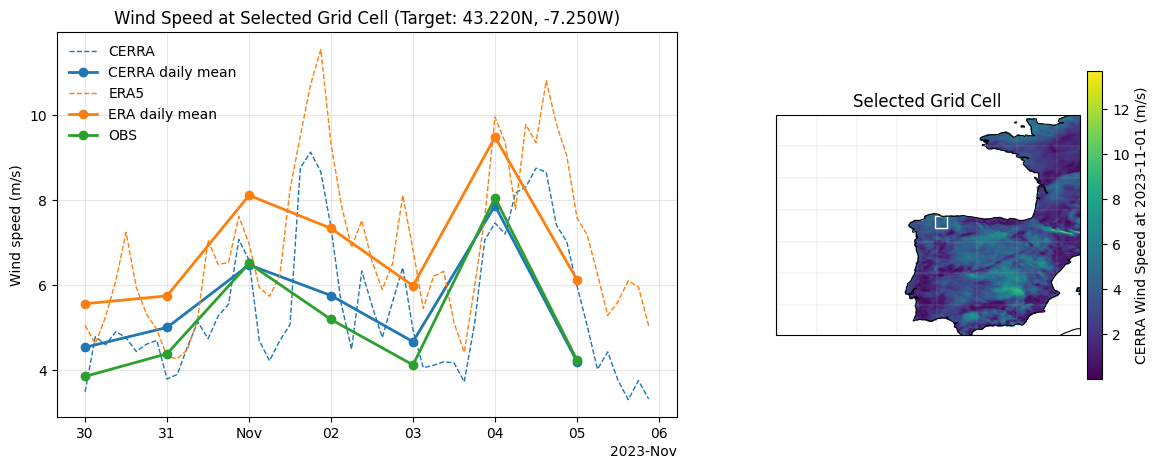

In [220]:
lat0 = 43.22
lon0 = -7.25
point_timeseries_with_locator(
    lat0, lon0, cerra_ds, era_ds, obsar_raw, "si10", "wind_speed", "fg", 2
)

In [224]:
import subprocess

subprocess.run(["python3", "-m", "nbconvert", "--to", "html", "Draft2_Ciarán.ipynb"])

[NbConvertApp] Converting notebook Draft2_Ciarán.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 3 image(s).
[NbConvertApp] Writing 3957891 bytes to Draft2_Ciarán.html


CompletedProcess(args=['python3', '-m', 'nbconvert', '--to', 'html', 'Draft2_Ciarán.ipynb'], returncode=0)